# Converting a keras model with HLS4ML

Check if your virtual enviroment is active!
Now let's get the dependecies ...

In [1]:
!which python

/home/fabbio/ProjectsLocal/tutorial-hls4ml/hls4ml/venv_hls4ml/bin/python


In [2]:
!pip install pydot graphviz

Installing a library for model quantization. 

Is not used here, but a needed dependency. 

Because of an issues an older version needs to be installed.

In [3]:
%%bash
git clone https://github.com/google/qkeras.git

Cloning into 'qkeras'...


In [5]:
%cd qkeras


/home/fabbio/ProjectsLocal/tutorial-hls4ml/hls4ml/qkeras


In [7]:
%%bash
git checkout 244ebe8
python setup.py install

running install
running bdist_egg
running egg_info
creating QKeras.egg-info
writing QKeras.egg-info/PKG-INFO
writing dependency_links to QKeras.egg-info/dependency_links.txt
writing requirements to QKeras.egg-info/requires.txt
writing top-level names to QKeras.egg-info/top_level.txt
writing manifest file 'QKeras.egg-info/SOURCES.txt'
reading manifest file 'QKeras.egg-info/SOURCES.txt'
reading manifest template 'MANIFEST.in'
writing manifest file 'QKeras.egg-info/SOURCES.txt'
installing library code to build/bdist.linux-x86_64/egg
running install_lib
running build_py
creating build
creating build/lib
creating build/lib/qkeras
copying qkeras/quantizers.py -> build/lib/qkeras
copying qkeras/utils.py -> build/lib/qkeras
copying qkeras/estimate.py -> build/lib/qkeras
copying qkeras/b2t.py -> build/lib/qkeras
copying qkeras/qnormalization.py -> build/lib/qkeras
copying qkeras/safe_eval.py -> build/lib/qkeras
copying qkeras/qconvolutional.py -> build/lib/qkeras
copying qkeras/qpooling.py -> b

HEAD is now at 244ebe8 This patch is for better numerical behaviors: - Add alpha, get_scale function for binary and ternary quantizers. - Control the initial weight distribution with respect to fan-in of layers.
zip_safe flag not set; analyzing archive contents...


In [9]:
%cd ..

/home/fabbio/ProjectsLocal/tutorial-hls4ml/hls4ml


With the additional packages installed we can import the libraries needed.

In [13]:
import hls4ml
import yaml
import numpy as np
from utils import plotting
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import load_model

Declare the vivado path.

In [14]:
import os
os.environ['PATH'] = '/tools/Xilinx/Vivado/2019.2/bin:' + os.environ['PATH']

To be able to compare the hls and keras model, we need to load the test data and the keras model.

In [15]:
X_test = np.load(os.path.join('data','X_test.npy'), allow_pickle=True)
y_test = np.load(os.path.join('data','y_test.npy'), allow_pickle=True)
classes = np.load(os.path.join('data','classes.npy'), allow_pickle=True)

In [16]:
model = load_model('jet_tagging_keras/KERAS_check_best_model.h5')

To run the prediction execute:

In [17]:
y_keras = model.predict(X_test)

To use HLS4ML to it's full extend, the hls design can be adjusted and configurt.

These can be done by writing code or manually editing the yaml-file. 

Here the configuraton is set within the python code. 

A seperatly written file can be loaded for e.g. with
```
with open("keras-config.yml", 'r') as ymlfile:
    config = yaml.load(ymlfile, Loader=yaml.FullLoader)

```

Let's create the configuration out of the loaded model. 

In [18]:
config = hls4ml.utils.config_from_keras_model(model, granularity='name')
print("-----------------------------------")
plotting.print_dict(config)
print("-----------------------------------")

Interpreting Sequential
Topology:
Layer name: fc1_input, layer type: Input
Layer name: fc1, layer type: Dense
  -> Activation (linear), layer name: fc1
Layer name: relu1, layer type: Activation
Layer name: fc2, layer type: Dense
  -> Activation (linear), layer name: fc2
Layer name: relu2, layer type: Activation
Layer name: fc3, layer type: Dense
  -> Activation (linear), layer name: fc3
Layer name: relu3, layer type: Activation
Layer name: output, layer type: Dense
  -> Activation (linear), layer name: output
Layer name: softmax, layer type: Activation
-----------------------------------
LayerName
  fc1_input
    Precision
      result:        ap_fixed<16,6>
  fc1
    Precision
      weight:        ap_fixed<16,6>
      bias:          ap_fixed<16,6>
      result:        ap_fixed<16,6>
    ReuseFactor:     1
  fc1_linear
    Precision:       ap_fixed<16,6>
    ReuseFactor:     1
    table_size:      1024
    table_t:         ap_fixed<18,8>
  relu1
    Precision:       ap_fixed<16,6>
    

The network structure and the layer settings are shown above.
HLS4ML alows to adjust every layer seperatly. 

Now is the time to create the hls representation and run some profiling. A good explanation of the charts can be found [here](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/master/part2_advanced_config.ipynb).
```
The first thing to try is to numerically profile your model. This method plots the distribution of the weights (and biases) as a box and whisker plot. The grey boxes show the values which can be represented with the data types used in the hls_model. Generally, you need the box to overlap completely with the whisker 'to the right' (large values) otherwise you'll get saturation & wrap-around issues. It can be okay for the box not to overlap completely 'to the left' (small values), but finding how small you can go is a matter of trial-and-error.
```

We get an overview of the network structure and the weight distribution.

Interpreting Sequential
Topology:
Layer name: fc1_input, layer type: InputLayer, current shape: [[None, 16]]
Layer name: fc1, layer type: Dense, current shape: [[None, 16]]
Layer name: relu1, layer type: Activation, current shape: [[None, 64]]
Layer name: fc2, layer type: Dense, current shape: [[None, 64]]
Layer name: relu2, layer type: Activation, current shape: [[None, 32]]
Layer name: fc3, layer type: Dense, current shape: [[None, 32]]
Layer name: relu3, layer type: Activation, current shape: [[None, 32]]
Layer name: output, layer type: Dense, current shape: [[None, 32]]
Layer name: softmax, layer type: Softmax, current shape: [[None, 5]]
Creating HLS model
Profiling weights
Profiling activations
   fc1
   relu1
   fc2
   relu2
   fc3
   relu3
   output
   softmax


(<Figure size 432x288 with 1 Axes>, <Figure size 432x288 with 1 Axes>)

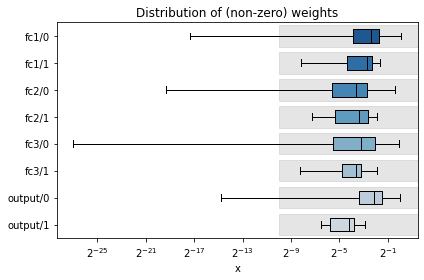

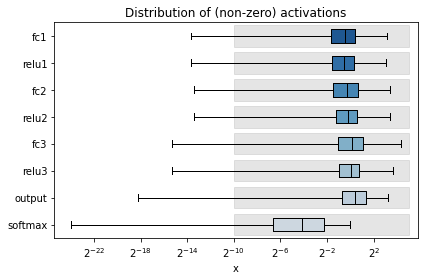

In [19]:
from hls4ml.model import profiling
hls_model = hls4ml.converters.convert_from_keras_model(model,
                                                       hls_config=config,
                                                       output_dir='model_jt/hls4ml_prj',
                                                       fpga_part='xc7a100tcsg324-1')

profiling.numerical(keras_model=model, hls_model=hls_model, X=X_test[:1000])

To edit entries inside the configuration, it can be used like a python dictionary.
Let's change the fixed-point size of the first layer and create the hls model again:

Interpreting Sequential
Topology:
Layer name: fc1_input, layer type: InputLayer, current shape: [[None, 16]]
Layer name: fc1, layer type: Dense, current shape: [[None, 16]]
Layer name: relu1, layer type: Activation, current shape: [[None, 64]]
Layer name: fc2, layer type: Dense, current shape: [[None, 64]]
Layer name: relu2, layer type: Activation, current shape: [[None, 32]]
Layer name: fc3, layer type: Dense, current shape: [[None, 32]]
Layer name: relu3, layer type: Activation, current shape: [[None, 32]]
Layer name: output, layer type: Dense, current shape: [[None, 32]]
Layer name: softmax, layer type: Softmax, current shape: [[None, 5]]
Creating HLS model
Profiling weights


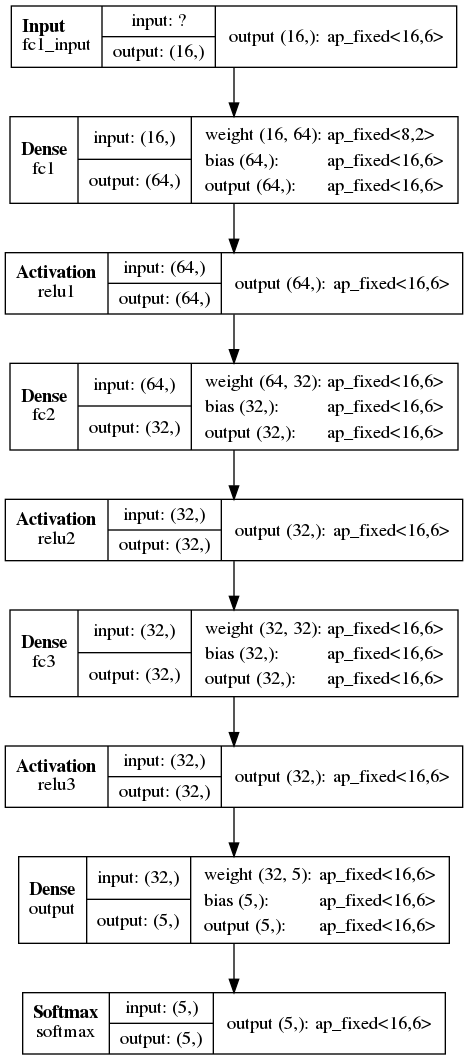

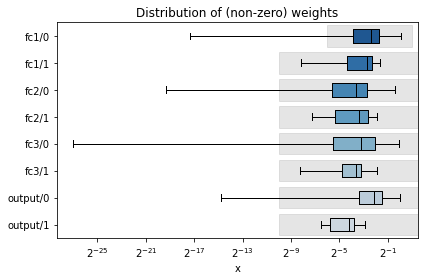

In [20]:
config['LayerName']['fc1']['Precision']['weight'] = 'ap_fixed<8,2>'
hls_model = hls4ml.converters.convert_from_keras_model(model,
                                                       hls_config=config,
                                                       output_dir='model_jt/hls4ml_prj',
                                                       fpga_part='xc7a100tcsg324-1')
profiling.numerical(keras_model=model, hls_model=hls_model)
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

If we want to know what happens inside the model because of our changes, we need to run the trace method.

First we change the entries accordingly and create the hls model.

In [26]:
for layer in config['LayerName'].keys():
    config['LayerName'][layer]['Trace'] = True
hls_model = hls4ml.converters.convert_from_keras_model(model,
                                                       hls_config=config,
                                                       output_dir='model_jt/hls4ml_prj',
                                                       fpga_part='xc7a100tcsg324-1')

Interpreting Sequential
Topology:
Layer name: fc1_input, layer type: InputLayer, current shape: [[None, 16]]
Layer name: fc1, layer type: Dense, current shape: [[None, 16]]
Layer name: relu1, layer type: Activation, current shape: [[None, 64]]
Layer name: fc2, layer type: Dense, current shape: [[None, 64]]
Layer name: relu2, layer type: Activation, current shape: [[None, 32]]
Layer name: fc3, layer type: Dense, current shape: [[None, 32]]
Layer name: relu3, layer type: Activation, current shape: [[None, 32]]
Layer name: output, layer type: Dense, current shape: [[None, 32]]
Layer name: softmax, layer type: Softmax, current shape: [[None, 5]]
Creating HLS model


Then the model needs to be compiled and we get the predictions of the individual layers.

In [22]:
hls_model.compile()
hls4ml_pred, hls4ml_trace = hls_model.trace(np.ascontiguousarray(X_test[:1000]))

Writing HLS project
Done
Recompiling myproject with tracing
Writing HLS project
Done


To compare it with the results of the keras model, we need to do the same here as well.

In [23]:
keras_trace = hls4ml.model.profiling.get_ymodel_keras(model,np.ascontiguousarray( X_test[:1000]))
y_hls = hls_model.predict(np.ascontiguousarray(X_test))

Processing fc1 in Keras model...
Processing relu1 in Keras model...
Processing fc2 in Keras model...
Processing relu2 in Keras model...
Processing fc3 in Keras model...
Processing relu3 in Keras model...
Processing output in Keras model...
Processing softmax in Keras model...
Done taking outputs for Keras model.


Now we can get the numerical representation of the predictions ...

In [24]:
print("Keras layer 'fc1', first sample:")
print(keras_trace['fc1'][0])
print("hls4ml layer 'fc1', first sample:")
print(hls4ml_trace['fc1'][0])

Keras layer 'fc1', first sample:
tf.Tensor(
[ 1.3290844  -0.2281767  -2.0335555  -1.2130377   0.74146473  1.3616108
  2.6107895   2.1303086   0.215912   -1.0871133   0.05874449 -0.2672279
  1.5067135   0.6213758  -0.70159614  0.70023733  0.23469554  0.4909886
  0.6733464   0.80200696  1.0611897   0.43017387  0.53745157 -1.078068
 -1.1115993   0.57993525 -0.58307314 -2.1476943   0.8633186   0.07018556
  1.8466957   0.6355359   0.12026603  0.75871754  1.3578072   1.3366797
  0.73120284 -2.3526006  -0.46800712 -0.06292731 -0.37440062  0.18880436
 -1.1856867  -0.79024667  1.5190511  -1.5934525   1.347016    1.9238378
 -1.593747   -1.7676041   0.5725447  -2.1265614  -1.5509636   1.7099267
  1.2837797   0.5545332  -1.1849121  -1.4780344   0.85579914  0.93257993
 -1.5022112   0.7201894  -1.261619   -1.0843174 ], shape=(64,), dtype=float32)
hls4ml layer 'fc1', first sample:
[ 1.31835938 -0.23535156 -2.06152344 -1.2421875   0.69921875  1.30957031
  2.5546875   2.07421875  0.17480469 -1.125     

Which is definitely more appealing in form of a graphical representation ...

Keras  Accuracy: 0.750210843373494
hls4ml Accuracy: 0.7494879518072289


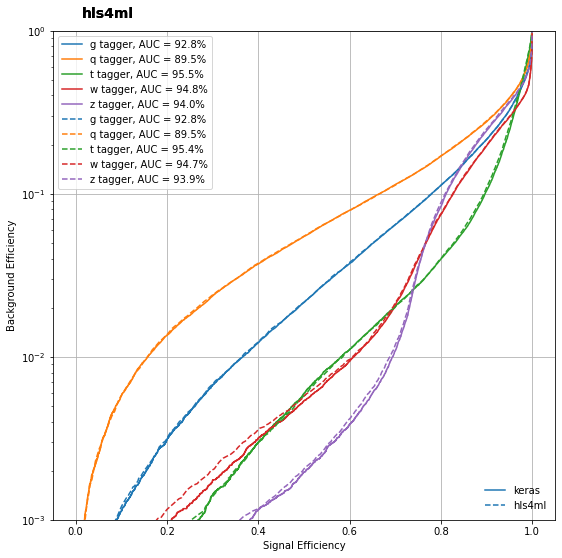

In [25]:
print("Keras  Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
print("hls4ml Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))

fig, ax = plt.subplots(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_keras, classes)
plt.gca().set_prop_cycle(None) # reset the colors
_ = plotting.makeRoc(y_test, y_hls, classes, linestyle='--')

from matplotlib.lines import Line2D
lines = [Line2D([0], [0], ls='-'),
         Line2D([0], [0], ls='--')]
from matplotlib.legend import Legend
leg = Legend(ax, lines, labels=['keras', 'hls4ml'],
            loc='lower right', frameon=False)
ax.add_artist(leg)

Beside the fixed-point size, an other important setting is the reuse factor. 

So let's change it for the whole model.

This won't affect the latency but the useage of MAC units and logic elements.

Interpreting Sequential
Topology:
Layer name: fc1_input, layer type: Input
Layer name: fc1, layer type: Dense
  -> Activation (linear), layer name: fc1
Layer name: relu1, layer type: Activation
Layer name: fc2, layer type: Dense
  -> Activation (linear), layer name: fc2
Layer name: relu2, layer type: Activation
Layer name: fc3, layer type: Dense
  -> Activation (linear), layer name: fc3
Layer name: relu3, layer type: Activation
Layer name: output, layer type: Dense
  -> Activation (linear), layer name: output
Layer name: softmax, layer type: Activation
-----------------------------------
{'Model': {'Precision': 'ap_fixed<16,6>', 'ReuseFactor': 1, 'Strategy': 'Latency'}}
-----------------------------------
Interpreting Sequential
Topology:
Layer name: fc1_input, layer type: InputLayer, current shape: [[None, 16]]
Layer name: fc1, layer type: Dense, current shape: [[None, 16]]
Layer name: relu1, layer type: Activation, current shape: [[None, 64]]
Layer name: fc2, layer type: Dense, curre

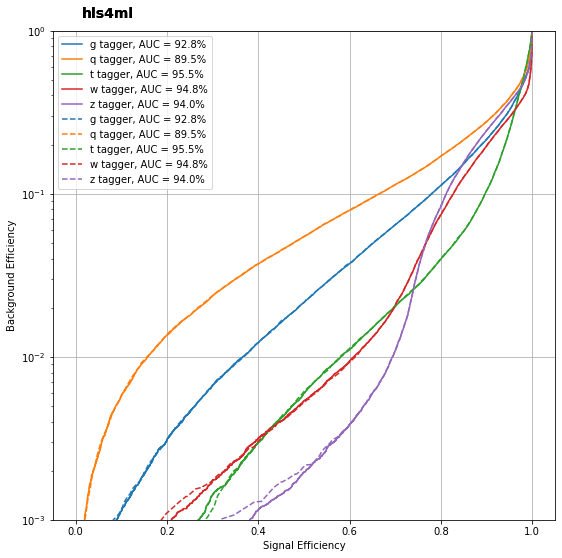

In [19]:
config = hls4ml.utils.config_from_keras_model(model, granularity='Model')
print("-----------------------------------")
print(config)
print("-----------------------------------")
# Set the ReuseFactor to 2 throughout
config['Model']['ReuseFactor'] = 2
hls_model = hls4ml.converters.convert_from_keras_model(model,
                                                       hls_config=config,
                                                       output_dir='model_std/hls4ml_prj',
                                                       fpga_part='xc7a100tcsg324-1')
hls_model.compile()
y_hls = hls_model.predict(np.ascontiguousarray(X_test))
print("Keras  Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
print("hls4ml Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))
plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_keras, classes)
plt.gca().set_prop_cycle(None) # reset the colors
_ = plotting.makeRoc(y_test, y_hls, classes, linestyle='--')

In [27]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

Failed to import pydot. You must install pydot and graphviz for `pydotprint` to work.


After compilation the hls model is ready to use and 
we will run some predictions.

In [ ]:
hls_model.compile()
y_hls = hls_model.predict(X_test)

This will start vivado and run the synthesis. 
The process can take some time, to monitor the logs run the command below inside a new console:
    tail -f model_std/hls4ml_prj/vivado_hls.log

In [ ]:
hls_model.build(csim=False)

And let's have a look at the report.

In [ ]:
hls4ml.report.read_vivado_report('model_std/hls4ml_prj/')